# Project Title - Patient Risk Intelligence
This project analyzes diabetes patient data to identify risk patterns using data preprocessing, exploratory data analysis (EDA), clustering, outlier detection, and risk scoring.
### Data Loading
The diabetes dataset is loaded from the raw data folder for preprocessing and analysis.
### Preprocessing
Invalid zero values in Glucose, BloodPressure, BMI, and Insulin are treated as missing values. Missing values are imputed using median values. Additional features such as AgeBand and BMICategory are created.
### Outlier Detection
The Interquartile Range (IQR) method is used to identify unusual insulin measurements.
### EDA
The dataset is explored using histograms, boxplots, and correlation heatmaps to identify important trends and relationships.
### Clustering
K-Means clustering groups patients into Low, Medium, and High Risk categories based on Age, BMI, and Glucose.
### Risk Scoring
A custom risk score is calculated using:  
Risk Score = (Glucose × 0.4) + (BMI × 0.3) + (Age × 0.3)  
Scores are normalized to a 0–100 scale.

In [ ]:
import sys
import importlib

sys.path.append("../src")

import preprocess
importlib.reload(preprocess)

from preprocess import load_data, preprocess_data

df = load_data("../data/raw/diabetes.csv")
df = preprocess_data(df)
df.to_csv(
        "../data/processed/cleaned_patients.csv",
        index=False
    )

print("Cleaned data saved successfully!")
print(df["BMICategory"].value_counts())
df.head()

Cleaned data saved successfully!
BMICategory
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeBand,BMICategory
0,6,148.0,72.0,35,0,33.6,0.627,50,1,50+,Obese
1,1,85.0,66.0,29,0,26.6,0.351,31,0,30-40,Overweight
2,8,183.0,64.0,0,0,23.3,0.672,32,1,30-40,Normal
3,1,89.0,66.0,23,94,28.1,0.167,21,0,20-30,Overweight
4,0,137.0,40.0,35,168,43.1,2.288,33,1,30-40,Obese


In [37]:
import sys
import importlib

sys.path.append("../src")

import preprocess
importlib.reload(preprocess)

from preprocess import load_data, preprocess_data

df = load_data("../data/raw/diabetes.csv")
df = preprocess_data(df)
df.to_csv(
        "../data/processed/cleaned_patients.csv",
        index=False
    )

print("Cleaned data saved successfully!")
print(df["BMICategory"].value_counts())
df.head()

Cleaned data saved successfully!
BMICategory
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeBand,BMICategory
0,6,148.0,72.0,35,0,33.6,0.627,50,1,50+,Obese
1,1,85.0,66.0,29,0,26.6,0.351,31,0,30-40,Overweight
2,8,183.0,64.0,0,0,23.3,0.672,32,1,30-40,Normal
3,1,89.0,66.0,23,94,28.1,0.167,21,0,20-30,Overweight
4,0,137.0,40.0,35,168,43.1,2.288,33,1,30-40,Obese


In [39]:

df = load_data("../data/processed/cleaned_patients.csv")
df= preprocess_data(df)
print(report)
df.head()

Glucose          0
BloodPressure    0
BMI              0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeBand,BMICategory
0,6,148.0,72.0,35,0,33.6,0.627,50,1,50+,Obese
1,1,85.0,66.0,29,0,26.6,0.351,31,0,30-40,Overweight
2,8,183.0,64.0,0,0,23.3,0.672,32,1,30-40,Normal
3,1,89.0,66.0,23,94,28.1,0.167,21,0,20-30,Overweight
4,0,137.0,40.0,35,168,43.1,2.288,33,1,30-40,Obese


Q1: 0.0
Q3: 127.25
IQR: 127.25
Lower Bound: -190.875
Upper Bound: 318.125
Number of Outliers: 34
Outliers: 34


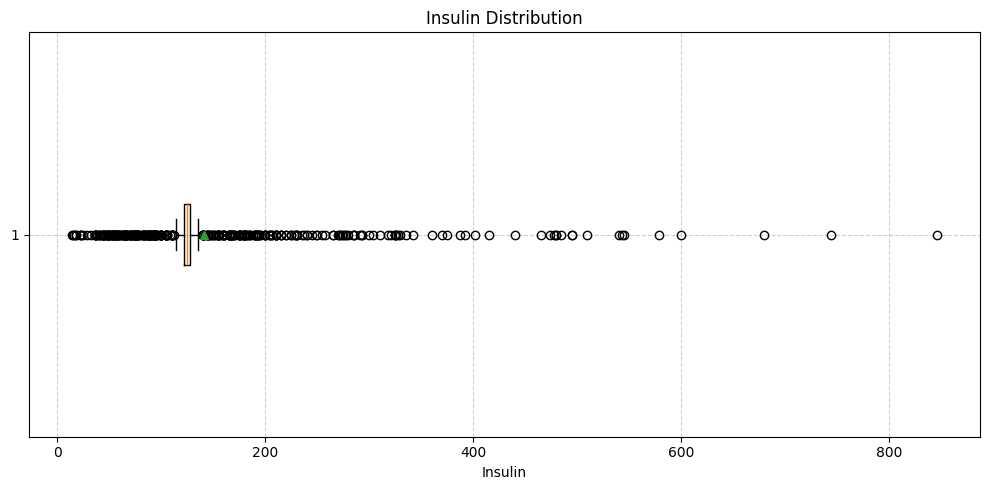

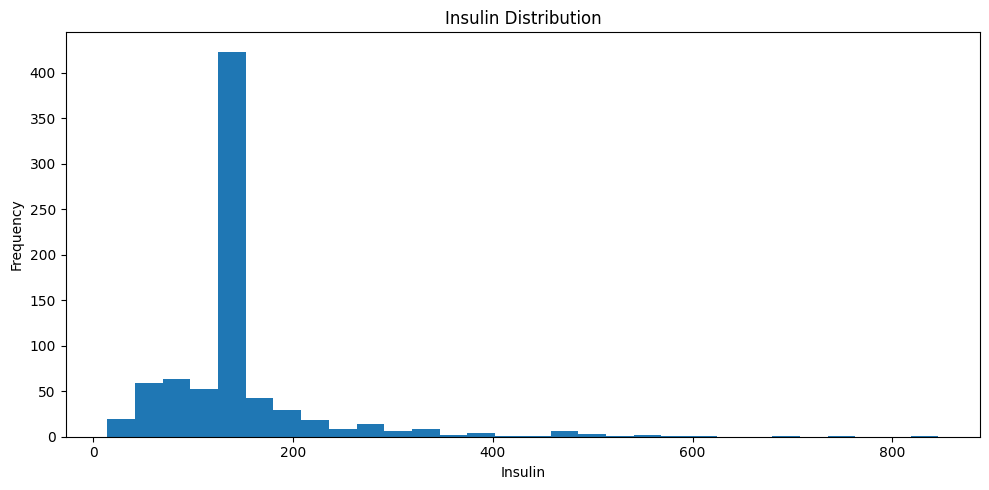

In [46]:


import outlier_detection
importlib.reload(outlier_detection)
from outlier_detection import detect_insulin_outliers, plot_insulin_boxplot,insulin_distribution

df, outlier_count = detect_insulin_outliers(df)

print("Outliers:", outlier_count)

plot_insulin_boxplot(df)
insulin_distribution(df)

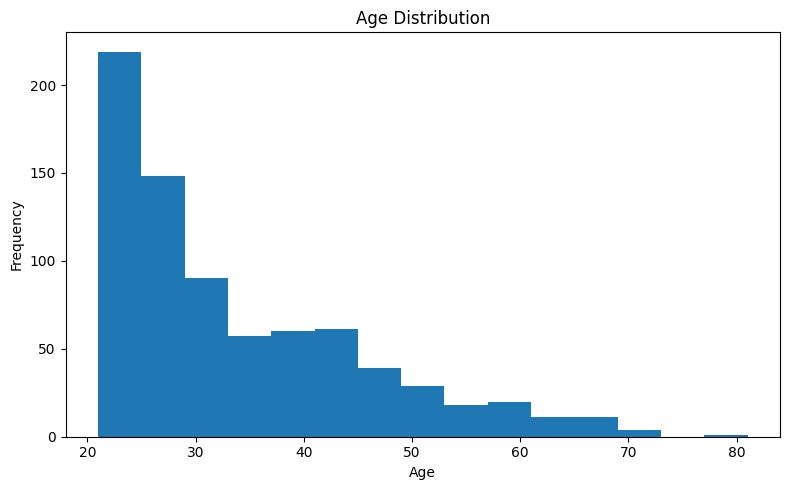

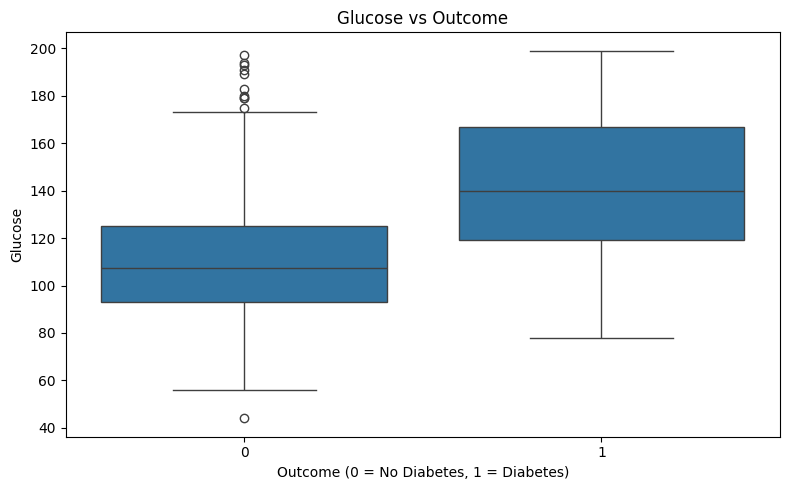

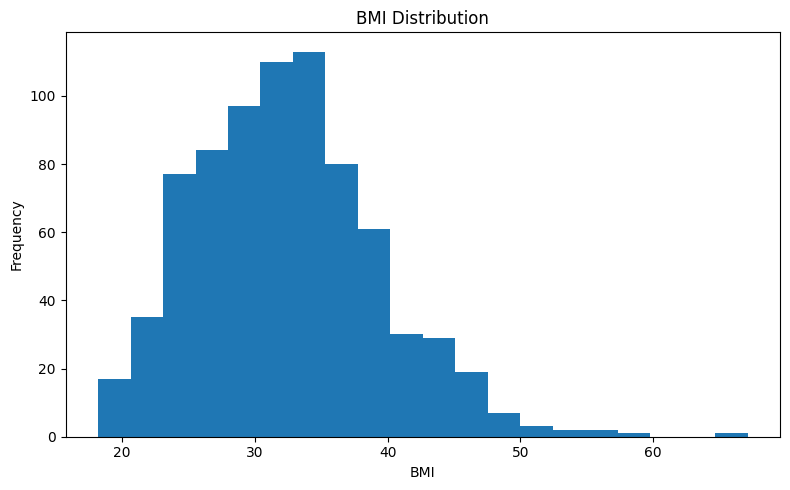

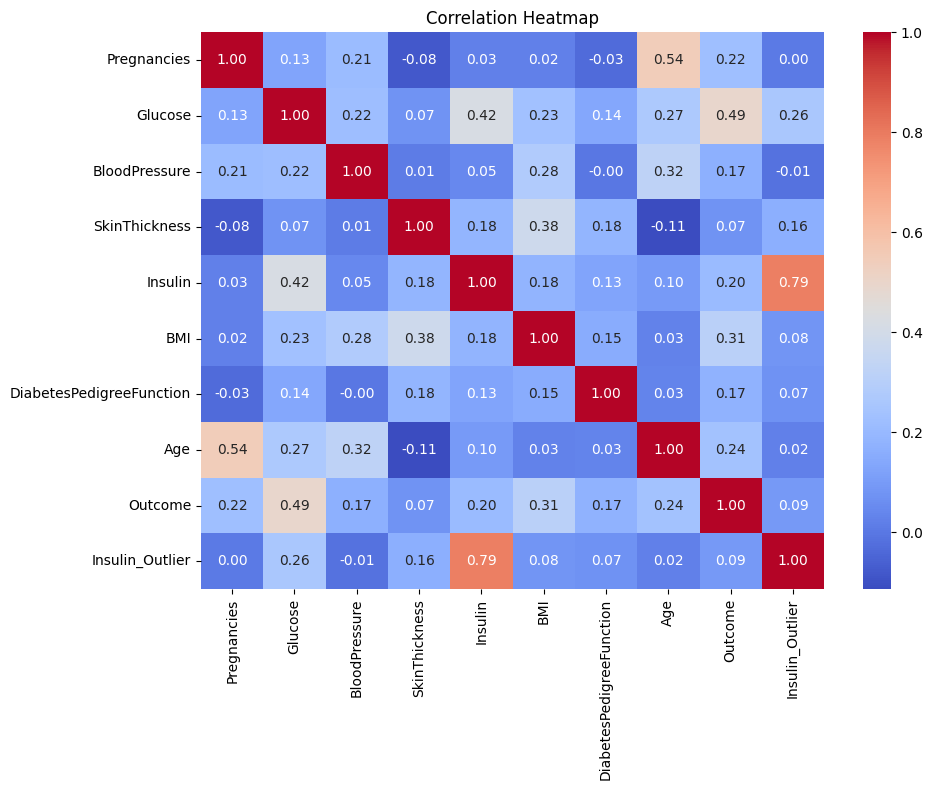

In [47]:

from eda import (
    age_distribution,
    glucose_vs_outcome,
    bmi_distribution,
    correlation_heatmap
)

age_distribution(df)
glucose_vs_outcome(df)
bmi_distribution(df)
correlation_heatmap(df)


Cluster Centers:
      Glucose        BMI        Age
0  158.024390  37.498780  30.579268
1  103.257009  30.557477  27.007009
2  132.511364  32.370455  50.880682

Risk Group Counts:
RiskGroup
Low Risk       428
Medium Risk    176
High Risk      164
Name: count, dtype: int64


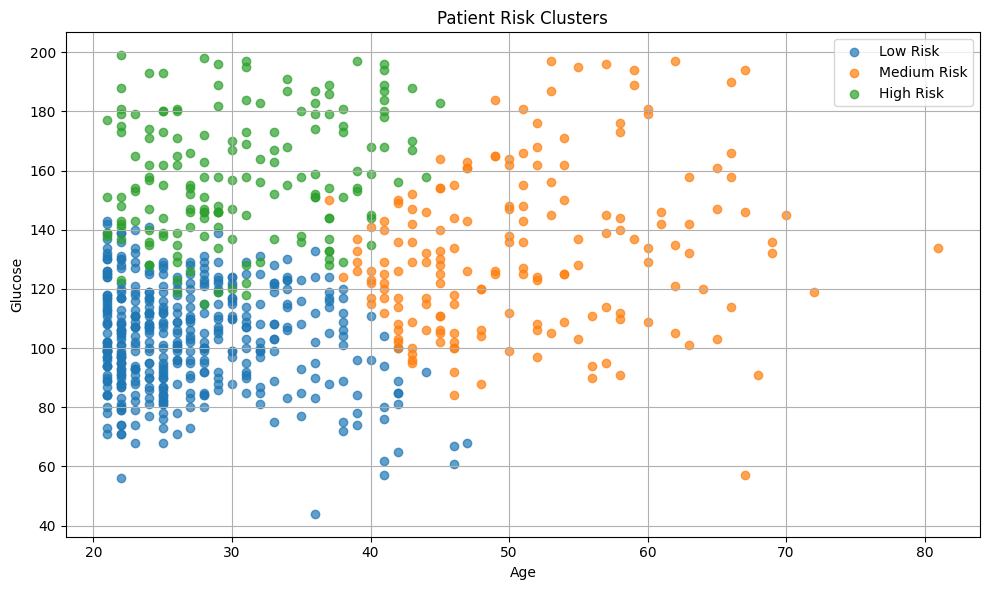

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeBand,BMICategory,Insulin_Outlier,Cluster,RiskGroup
0,6,148.0,72.0,35,125.0,33.6,0.627,50,1,50+,Obese,False,2,Medium Risk
1,1,85.0,66.0,29,125.0,26.6,0.351,31,0,30-40,Overweight,False,1,Low Risk
2,8,183.0,64.0,0,125.0,23.3,0.672,32,1,30-40,Normal,False,0,High Risk
3,1,89.0,66.0,23,94.0,28.1,0.167,21,0,20-30,Overweight,False,1,Low Risk
4,0,137.0,40.0,35,168.0,43.1,2.288,33,1,30-40,Obese,False,0,High Risk


In [48]:
from clustering import run_clustering, plot_clusters

df, centers = run_clustering(df)

plot_clusters(df)

df.head()

In [49]:
from risk_scoring import calculate_risk_score

df = calculate_risk_score(df)

df[["Glucose", "BMI", "Age", "RiskScore"]].head()

,Glucose,BMI,Age,RiskScore
0,148.0,33.6,50,67.28
1,85.0,26.6,31,21.39
2,183.0,23.3,32,74.94
3,89.0,28.1,21,20.07
4,137.0,43.1,33,58.03


## Raw Data → Preprocessing → EDA → Outlier Detection → Clustering → Risk Scoring → Final Dataset.

In [52]:
import sys
sys.path.append("../src")

from preprocess import load_data, preprocess_data
from clustering import run_clustering
from risk_scoring import calculate_risk_score

# Load raw data
df = load_data("../data/raw/diabetes.csv")

# Step 1: Preprocessing
df = preprocess_data(df)

# Step 2: Clustering
df, centers = run_clustering(df)

# Rename for final requirement
df["ClusterLabel"] = df["RiskGroup"]

# Step 3: Risk Scoring
df = calculate_risk_score(df)

# Save final dataset
df.to_csv(
    "../data/processed/cleaned_patients.csv",
    index=False
)

# Verify columns
required_columns = [
    "AgeBand",
    "BMICategory",
    "ClusterLabel",
    "RiskScore"
]
print()
print("Verification Results:")
for col in required_columns:
    print(f"{col}: {'Present' if col in df.columns else 'Missing'}")

print("\nDataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())


Cluster Centers:
      Glucose        BMI        Age
0  158.024390  37.498780  30.579268
1  103.257009  30.557477  27.007009
2  132.511364  32.370455  50.880682

Risk Group Counts:
RiskGroup
Low Risk       428
Medium Risk    176
High Risk      164
Name: count, dtype: int64

Verification Results:
AgeBand: Present
BMICategory: Present
ClusterLabel: Present
RiskScore: Present

Dataset Shape: (768, 16)

Final Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'AgeBand', 'BMICategory', 'Cluster', 'RiskGroup', 'ClusterLabel', 'RawRiskScore', 'RiskScore']
